## Importing the Dependencies

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

In [2]:
# loading the data from csv file to a Pandas DataFrame.
df = pd.read_csv("winequality-red.csv")
print(df)

      fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0               7.4             0.700         0.00             1.9      0.076   
1               7.8             0.880         0.00             2.6      0.098   
2               7.8             0.760         0.04             2.3      0.092   
3              11.2             0.280         0.56             1.9      0.075   
4               7.4             0.700         0.00             1.9      0.076   
...             ...               ...          ...             ...        ...   
1594            6.2             0.600         0.08             2.0      0.090   
1595            5.9             0.550         0.10             2.2      0.062   
1596            6.3             0.510         0.13             2.3      0.076   
1597            5.9             0.645         0.12             2.0      0.075   
1598            6.0             0.310         0.47             3.6      0.067   

      free sulfur dioxide  

In [3]:
# Column Descriptions

# Independent Variables

#1) fixed acidity(Numerical - Continuous) :- Non-volatile acids that do not evaporate easily (e.g., tartaric acid).

#2) volatile acidity(Numerical - Continuous):- Amount of acetic acid in wine.

#3) citric acid(Numerical - Continuous):- Amount of citric acid present in wine.

#4) residual sugar(Numerical - Continuous):- Sugar remaining after fermentation.

#5) chlorides(Numerical - Continuous):- Amount of salt in wine.

#6) free sulfur dioxide(Numerical - Continuous):- Free SO₂ available for microbial protection.

#7) total sulfur dioxide(Numerical - Continuous):- Total amount of SO₂(free + bound forms).

#8) density(Numerical - Continuous):- Density of wine.

#9) pH(Numerical - Continuous):- Acidity level of wine (scale 0–14).

#10) sulphates(Numerical - Continuous) :- Potassium sulphate level in wine.

#11) alcohol(Numerical - Continuous):- Alcohol percentage by volume.


#  Dependent(Target) Variable / Output Feature :- 
# quality(Categorical (Ordinal)):- Wine quality score assigned by experts.

## EDA on this Dataset.

In [4]:
# Get the Quick Overview of the Dataset and Understand the structure of the Dataset.

df.shape  # Rows and Columns of the Dataset.
print("Infornmation about the Dataset")
df.info() # Complete Infornmation about the Columns of the Dataset.
df.columns # Infornmation i.e. Names of the Columns about the Dataset.
df.head(5) # Top 5 Rows of the Dataset.
df.tail(5) # Last 5 Rows of the Dataset.
df.dtypes # Getting Data - Types of each Column in the Dataset.
df.count()  # Count Non-Null Values in Each Column.
df.dtypes # Determining the Data - type of Columns in the Dataset.

Infornmation about the Dataset
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


fixed acidity           float64
volatile acidity        float64
citric acid             float64
residual sugar          float64
chlorides               float64
free sulfur dioxide     float64
total sulfur dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
quality                   int64
dtype: object

In [6]:
# Checking for the Missing Vaues i.e. find out the Missing Values.

print(df.isnull()) # Null - Values in the form of Boolean Matrix(True - Missing Values , False - Not a mssing Values).
print(df.notnull()) # Opposite of isnull(True - Not a Missing Values , False - Missing Values)
print(df.isnull().sum()) # Count of the Missing Values of each Columns.
# By illustration, it is clear there are no missing values in any column in the Dataset.

      fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0             False             False        False           False      False   
1             False             False        False           False      False   
2             False             False        False           False      False   
3             False             False        False           False      False   
4             False             False        False           False      False   
...             ...               ...          ...             ...        ...   
1594          False             False        False           False      False   
1595          False             False        False           False      False   
1596          False             False        False           False      False   
1597          False             False        False           False      False   
1598          False             False        False           False      False   

      free sulfur dioxide  

In [7]:
# Handling Duplicates in the Dataset.

print(df.duplicated())  # Reurns a Boolean series i.e. True denotes Duplicate Value and False denotes Not a Duplicate Value.
print(df.duplicated().sum()) # Sum of the Duplicate Values of the rows in the dataset(415 here).
df = df.drop_duplicates() #Dropping the Duplicate Rows in the Dataset.
print(df)

0       False
1       False
2       False
3       False
4        True
        ...  
1594    False
1595    False
1596     True
1597    False
1598    False
Length: 1599, dtype: bool
240
      fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0               7.4             0.700         0.00             1.9      0.076   
1               7.8             0.880         0.00             2.6      0.098   
2               7.8             0.760         0.04             2.3      0.092   
3              11.2             0.280         0.56             1.9      0.075   
5               7.4             0.660         0.00             1.8      0.075   
...             ...               ...          ...             ...        ...   
1593            6.8             0.620         0.08             1.9      0.068   
1594            6.2             0.600         0.08             2.0      0.090   
1595            5.9             0.550         0.10             2.2      0.062   
1597  

## Univariate Analysis

## fixed acidity Column

In [8]:
df['fixed acidity'].describe() # Statisical Summary of fixed acidity Column 

count    1359.000000
mean        8.310596
std         1.736990
min         4.600000
25%         7.100000
50%         7.900000
75%         9.200000
max        15.900000
Name: fixed acidity, dtype: float64

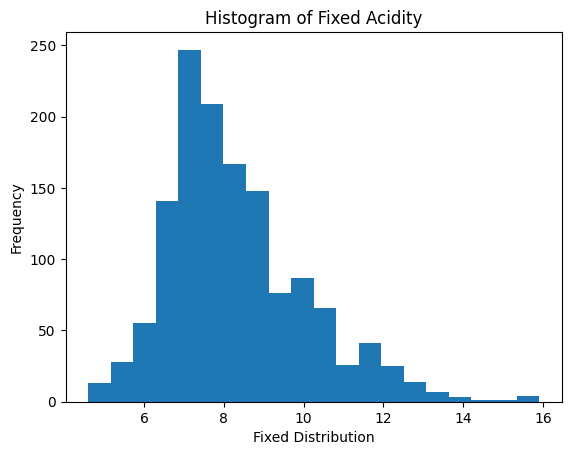

In [11]:
# Histogram

plt.figure()
plt.hist(df['fixed acidity'], bins=20)
plt.title("Histogram of Fixed Acidity")
plt.xlabel("Fixed Distribution")
plt.ylabel("Frequency")
plt.show()

## Bivariate Analysis

## alcohol vs quality Columns

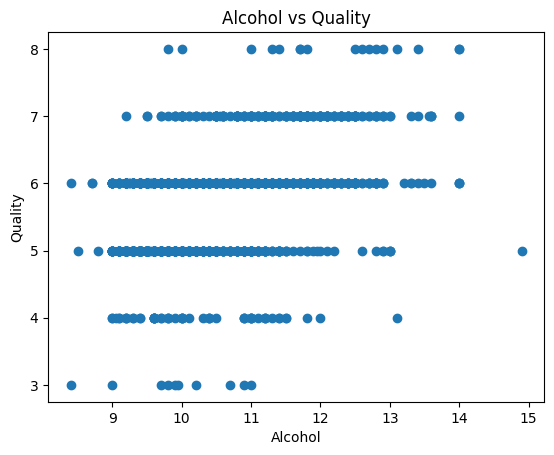

In [13]:
plt.figure()
plt.scatter(df["alcohol"], df["quality"])
plt.xlabel("Alcohol")
plt.ylabel("Quality")
plt.title("Alcohol vs Quality")
plt.show()

## Correlation Matrix

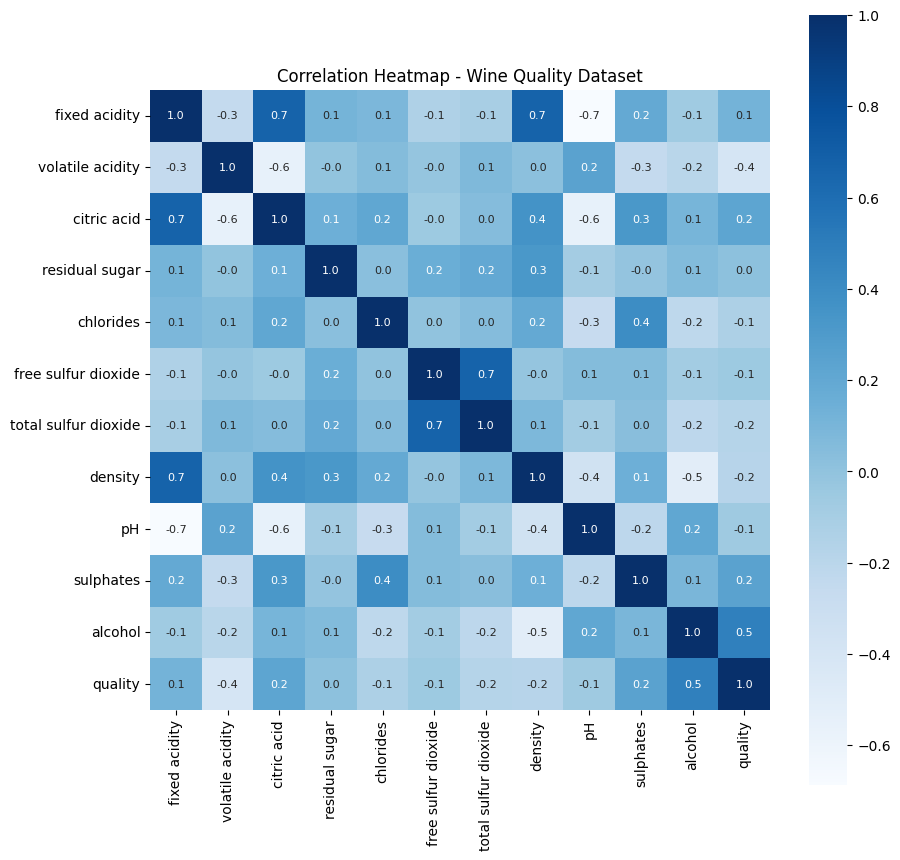

In [15]:
# Compute Correlation Matrix

correlation = df.corr()

# Plot Heatmap
plt.figure(figsize=(10,10))

sns.heatmap(
    correlation,
    cbar=True,
    square=True,
    fmt='.1f',
    annot=True,
    annot_kws={'size':8},
    cmap='Blues'
)

plt.title("Correlation Heatmap - Wine Quality Dataset")
plt.show()

## Data Preprocessing

In [16]:
# separate the data and Label.
X = df.drop('quality',axis=1)

In [17]:
print(X)

      fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0               7.4             0.700         0.00             1.9      0.076   
1               7.8             0.880         0.00             2.6      0.098   
2               7.8             0.760         0.04             2.3      0.092   
3              11.2             0.280         0.56             1.9      0.075   
5               7.4             0.660         0.00             1.8      0.075   
...             ...               ...          ...             ...        ...   
1593            6.8             0.620         0.08             1.9      0.068   
1594            6.2             0.600         0.08             2.0      0.090   
1595            5.9             0.550         0.10             2.2      0.062   
1597            5.9             0.645         0.12             2.0      0.075   
1598            6.0             0.310         0.47             3.6      0.067   

      free sulfur dioxide  

- Label Binarizaton:-
  Label Binarization is a data preprocessing technique used in Machine Learning and Exploratory Data Analysis (EDA) to convert categorical or multi-class label data into a binary format (0s and 1s)

In [19]:
Y = df['quality'].apply(lambda y_value: 1 if y_value>=7 else 0)

In [20]:
print(Y)

0       0
1       0
2       0
3       0
5       0
       ..
1593    0
1594    0
1595    0
1597    0
1598    0
Name: quality, Length: 1359, dtype: int64


## Splitting the data into training data & test data.


In [21]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=3)

In [22]:
print(Y.shape, Y_train.shape, Y_test.shape)


(1359,) (1087,) (272,)


## Model Training(Random Forest Classifier)


In [23]:
model = RandomForestClassifier()

In [24]:
model.fit(X_train, Y_train)

RandomForestClassifier()

## Model Evaluation

## Accuracy Score

In [27]:
# Accuracy on training data

X_train_prediction = model.predict(X_train)
training_data_accuracy = accuracy_score(X_train_prediction, Y_train)

print("Accuracy on Training Data:", training_data_accuracy)

Accuracy on Training Data: 1.0


In [28]:
# Accuracy on test data.

X_test_prediction = model.predict(X_test)
test_data_accuracy = accuracy_score(X_test_prediction, Y_test)

In [26]:
print('Accuracy : ', test_data_accuracy)

Accuracy :  0.8970588235294118


## Building a Predictive System.

In [30]:
input_data = (7.5,0.5,0.36,6.1,0.071,17.0,102.0,0.9978,3.35,0.8,10.5)

# changing the input data to a numpy array
input_data_as_numpy_array = np.asarray(input_data)

# reshape the data as we are predicting the label for only one instance
input_data_reshaped = input_data_as_numpy_array.reshape(1,-1)

prediction = model.predict(input_data_reshaped)
print(prediction)

if (prediction[0]==1):
  print('Good Quality Wine')
else:
  print('Bad Quality Wine')

[0]
Bad Quality Wine


C:\Users\abhis\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
